# Deep Learning-Based Plant Disease Identification Using Convolutional Neural Networks

## Convolutional Neural Network (CNN)

### Proyek Pengganti UAS  
Mata Kuliah Kecerdasan Buatan  
Semester Genap 2025/2026  

---

## Disusun Oleh

| Nama | NPM |
|---|---|
| Nabiel Harits Utomo | 2306267044 |
| Muhammad Pavel | 2306242363 |
| R. Aisha Syauqi Ramadhani | 2306250554 |
| Zhafira Zahra Alfarisy | 2306250636 |

---

## Dosen Pengampu
Muhammad Firdaus Syawaludin Lubis, S.T., M.T., Ph.D.

# Deskripsi Proyek

Proyek ini bertujuan untuk membangun model klasifikasi penyakit daun tanaman menggunakan pendekatan Deep Learning berbasis Convolutional Neural Network (CNN).

Dataset yang digunakan berasal dari PlantVillage Dataset dengan fokus pada klasifikasi beberapa jenis penyakit daun tomat.

Pada proyek ini dilakukan:
- preprocessing data,
- pelatihan baseline CNN,
- evaluasi performa model,
- serta pengembangan lanjutan menggunakan transfer learning.

Model akan dievaluasi menggunakan metrik accuracy dan visualisasi training.

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Menghubungkan Google Drive

Dataset proyek disimpan pada Google Drive agar dapat diakses langsung melalui Google Colab.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Path Dataset

Dataset yang digunakan adalah PlantVillage Dataset yang telah disimpan pada Google Drive.

In [4]:
dataset_path = "/content/drive/MyDrive/plant_disease_dataset"

# print("Dataset Path:", dataset_path)

# Data Preprocessing

Tahapan preprocessing meliputi:
- resize gambar,
- normalisasi piksel,
- data augmentation,
- pembagian data training dan validation.

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 5780 images belonging to 5 classes.
Found 1443 images belonging to 5 classes.


# Informasi Kelas Dataset

Berikut merupakan daftar kelas penyakit tanaman yang digunakan dalam proyek.

In [7]:
print("Classes:")
print(train_data.class_indices)

Classes:
{'Tomato_Early_blight': 0, 'Tomato_Late_blight': 1, 'Tomato_Leaf_Mold': 2, 'Tomato_Septoria_leaf_spot': 3, 'Tomato_healthy': 4}


# Visualisasi Dataset

Berikut beberapa contoh citra daun tanaman dari dataset.

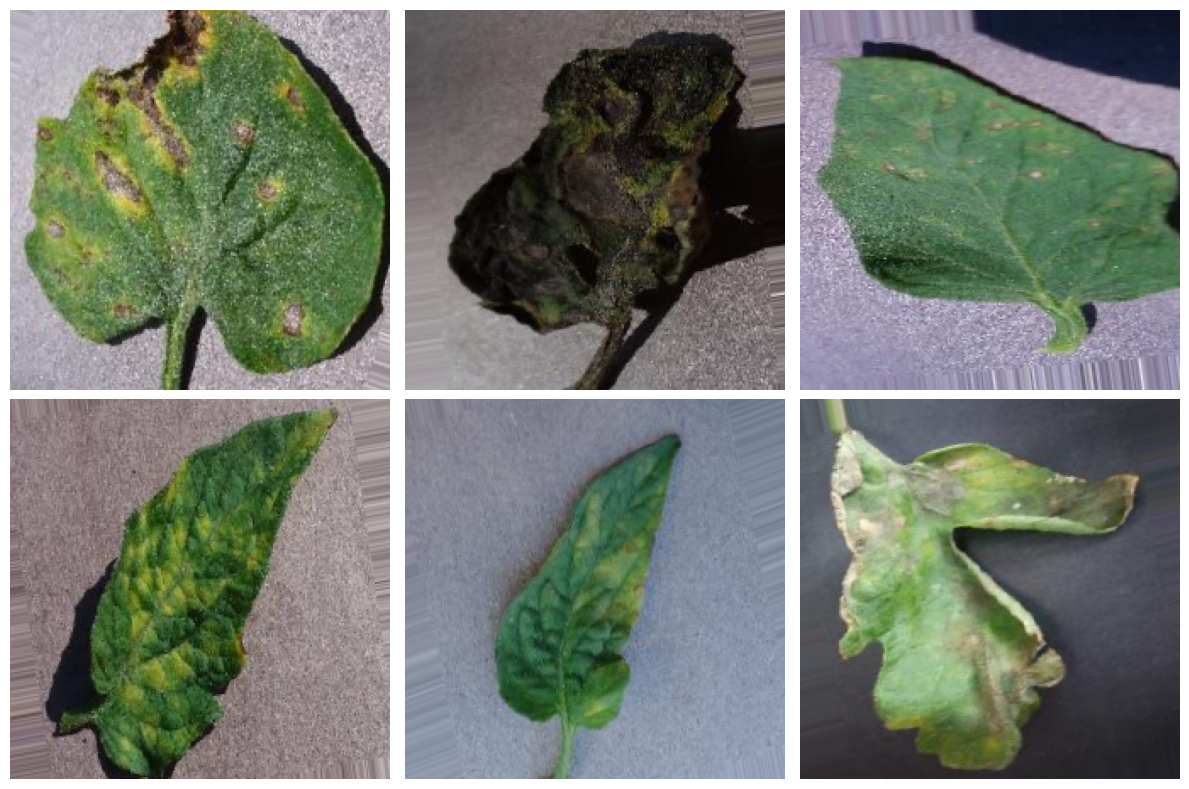

In [8]:
images, labels = next(train_data)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# Arsitektur Baseline CNN

Model baseline CNN terdiri dari:
- Convolution Layer
- ReLU Activation
- MaxPooling Layer
- Dense Layer
- Dropout Regularization

Model digunakan sebagai baseline awal untuk klasifikasi penyakit tanaman.

In [9]:
model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(
        train_data.num_classes,
        activation='softmax'
    )
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

Model dikompilasi menggunakan:
- optimizer Adam,
- categorical crossentropy loss,
- accuracy sebagai metrik evaluasi.

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training Model

Proses training dilakukan menggunakan dataset training dan validation selama beberapa epoch.

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 3996s 22s/step - accuracy: 0.4197 - loss: 1.3497 - val_accuracy: 0.7089 - val_loss: 0.8607
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 110s 611ms/step - accuracy: 0.7031 - loss: 0.7807 - val_accuracy: 0.7983 - val_loss: 0.4932
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 130s 719ms/step - accuracy: 0.7760 - loss: 0.5867 - val_accuracy: 0.8184 - val_loss: 0.4657
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 112s 620ms/step - accuracy: 0.8062 - loss: 0.5218 - val_accuracy: 0.8635 - val_loss: 0.3812
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 110s 608ms/step - accuracy: 0.8420 - loss: 0.4339 - val_accuracy: 0.8836 - val_loss: 0.3233
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 110s 608ms/step - accuracy: 0.8538 - loss: 0.4009 - val_accuracy: 0.8905 - val_loss: 0.3166
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 110s 607ms/step - accuracy: 0.8642 - loss: 0.3694 - val_accuracy: 0.9044 - val_loss: 0.2493
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 129s 713ms/step - accuracy: 0.8874 - 

# Grafik Accuracy

Grafik berikut menunjukkan perkembangan accuracy selama proses training dan validation.

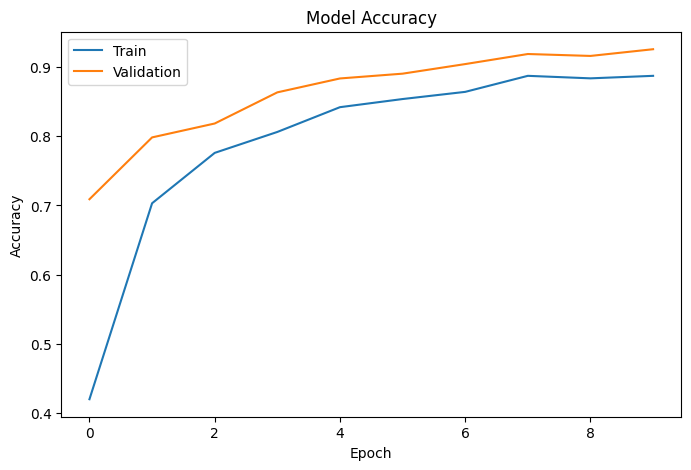

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

# Grafik Loss

Grafik berikut menunjukkan perubahan loss selama proses training.

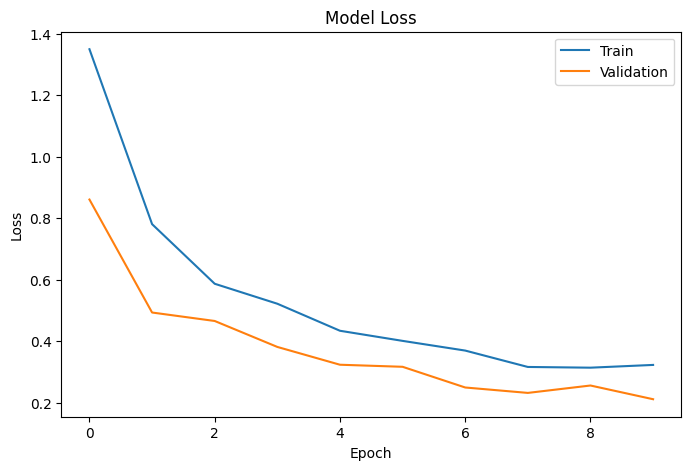

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

# Evaluasi Model

Model dievaluasi menggunakan dataset validation untuk memperoleh accuracy awal.

In [14]:
loss, accuracy = model.evaluate(val_data)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 444ms/step - accuracy: 0.9328 - loss: 0.2068
Validation Loss : 0.2067899852991104
Validation Accuracy : 0.9327789545059204


# Menyimpan Model

Model baseline CNN disimpan untuk kebutuhan evaluasi dan pengembangan lebih lanjut.

In [16]:
model.save("baseline_cnn.keras")

print("Model berhasil disimpan!")

Model berhasil disimpan!


# Kesimpulan

Model baseline CNN berhasil melakukan training awal untuk klasifikasi penyakit daun tanaman menggunakan PlantVillage Dataset.

Tahapan selanjutnya meliputi:
- implementasi transfer learning,
- hyperparameter tuning,
- confusion matrix analysis,
- serta perbandingan performa model.